In [37]:
import pynetlogo
import pandas as pd
import itertools
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Explicitly point to the libjvm.dylib file inside NetLogo's application package
# Path on GIS DESKTOP
jvm_path = "C:/Program Files/NetLogo 6.4.0/runtime/bin/server/jvm.dll"
netlogo_home = "C:/Program Files/NetLogo 6.4.0"

#Path on Mac Laptop
# jvm_path = "/Applications/NetLogo 6.4.0/runtime/Contents/Home/lib/server/libjvm.dylib"
# netlogo_home="/Applications/NetLogo 6.4.0"

netlogo = pynetlogo.NetLogoLink(
    gui=False,
    netlogo_home=netlogo_home,
    jvm_path=jvm_path 
)

# Path in GIS DESKTOP
model_path = "C:/Users/15177459/Desktop/Bachelor-Thesis/Netlogo/third_place_attributes.nlogo"

# Path in Mac Laptop
# model_path = "/Users/tonyvo/Desktop/Thesis/Bachelor-Thesis/Netlogo/third_place_attributes.nlogo"

netlogo.load_model(model_path)
netlogo.command("setup")

# Lingering vs Stop Probability

## High Transport High Third Place

In [9]:
stop_probs = [10, 30, 50]
dwell_multipliers = [0.5, 1.0, 1.5, 2.0]

base_rigid = 30
base_medium = 45
base_flexible = 60

results = []

seeds = [1, 2, 3, 4, 5]

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

for stop_prob in stop_probs:
    for multiplier in dwell_multipliers:
        
        rigid_dwell = base_rigid * multiplier
        medium_dwell = base_medium * multiplier
        flexible_dwell = base_flexible * multiplier
        
        # set parameters in NetLogo
        netlogo.command(f"set baseline-stop-probability {stop_prob}")
        netlogo.command(f"set rigid-dwell-time {rigid_dwell}")
        netlogo.command(f"set medium-dwell-time {medium_dwell}")
        netlogo.command(f"set flexible-dwell-time {flexible_dwell}")
        
        # keep other parameters constant
        netlogo.command("set number-of-people 200")
        netlogo.command("set third-place-search-radius 2")
        netlogo.command("set route-third-place-sample-size 50")
        netlogo.command("set encounter-odds-increment 0.10")
        netlogo.command("set encounter-weight 5")
        
        # run model
        for seed in seeds:
            netlogo.command(f"random-seed {seed}")
            netlogo.command("setup")
            netlogo.repeat_command("go", 1000)
        
            row = {
                "seed": seed,
                "baseline-stop-probability": stop_prob,
                "dwell-multiplier": multiplier,
                "rigid-dwell-time": rigid_dwell,
                "medium-dwell-time": medium_dwell,
                "flexible-dwell-time": flexible_dwell,
                    }

            for reporter in reporters:
                row[reporter] = netlogo.report(reporter)
            
            results.append(row)




exphi_hi = pd.DataFrame(results)
exphi_hi.head()

,seed,baseline-stop-probability,dwell-multiplier,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,visits-per-person,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,1,10,0.5,15.0,22.5,30.0,0.785,8.097297,1.20,1.1190,465.0,2.961783,23.0,9.0,0.121019,0.736904,0.723683
1,2,10,0.5,15.0,22.5,30.0,0.785,8.789274,2.70,1.2540,1093.0,6.961783,21.0,8.0,0.184713,0.728917,0.765406
2,3,10,0.5,15.0,22.5,30.0,0.705,8.647417,2.40,1.2105,990.0,7.021277,18.0,8.0,0.191489,0.702256,0.708872
3,4,10,0.5,15.0,22.5,30.0,0.680,8.375687,1.85,1.1815,743.0,5.463235,21.0,12.0,0.125000,0.718469,0.752610
4,5,10,0.5,15.0,22.5,30.0,0.735,8.508590,2.25,1.2005,852.0,5.795918,25.0,11.0,0.190476,0.619961,0.667618


In [16]:
grouped_hi_hi = exphi_hi.groupby(["baseline-stop-probability", "dwell-multiplier"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped_hi_hi


,baseline-stop-probability,dwell-multiplier,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,0.5,828.6,242.918299,0.738,2.08,0.162540,5.640799
1,10,1.0,3170.0,839.144803,0.772,4.92,0.149157,20.395477
2,10,1.5,6077.4,1048.664293,0.762,7.14,0.157175,39.698155
3,10,2.0,9269.8,1204.600017,0.768,10.36,0.153900,60.190538
4,30,0.5,6112.4,414.416216,2.240,22.96,0.144640,13.676912
5,30,1.0,14446.8,226.083392,2.126,39.77,0.157684,34.000122
6,30,1.5,22462.6,897.211402,2.021,58.24,0.158413,55.580637
7,30,2.0,29160.4,2423.310607,1.941,70.57,0.150356,75.022677
8,50,0.5,11072.8,383.601616,3.422,53.30,0.161865,16.202116
9,50,1.0,24037.2,1058.935645,3.199,96.01,0.147032,37.582629


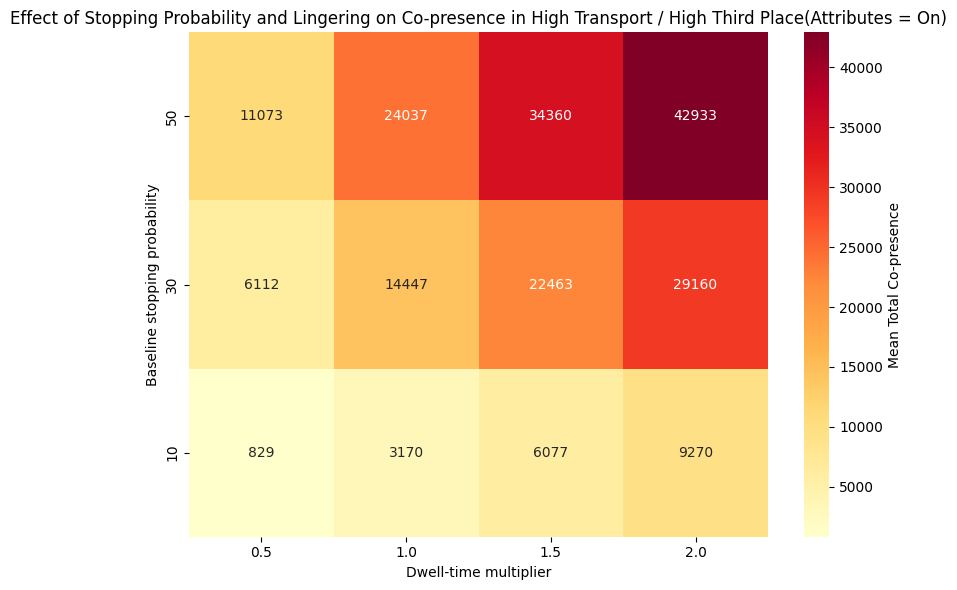

In [43]:
pivot = grouped_hi_hi.pivot(
    index="baseline-stop-probability",
    columns="dwell-multiplier",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Effect of Stopping Probability and Lingering on Co-presence in High Transport / High Third Place(Attributes = On)")
ax.set_xlabel("Dwell-time multiplier")
ax.set_ylabel("Baseline stopping probability")
plt.tight_layout()

## High Transport Low Third Place

In [29]:
stop_probs = [10, 30, 50]
dwell_multipliers = [0.5, 1.0, 1.5, 2.0]

base_rigid = 30
base_medium = 45
base_flexible = 60

results = []

seeds = [1, 2, 3, 4, 5]

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

for stop_prob in stop_probs:
    for multiplier in dwell_multipliers:
        
        rigid_dwell = base_rigid * multiplier
        medium_dwell = base_medium * multiplier
        flexible_dwell = base_flexible * multiplier
        
        # set parameters in NetLogo
        netlogo.command(f"set baseline-stop-probability {stop_prob}")
        netlogo.command(f"set rigid-dwell-time {rigid_dwell}")
        netlogo.command(f"set medium-dwell-time {medium_dwell}")
        netlogo.command(f"set flexible-dwell-time {flexible_dwell}")
        
        # keep other parameters constant
        netlogo.command("set number-of-people 200")
        netlogo.command("set third-place-search-radius 2")
        netlogo.command("set route-third-place-sample-size 50")
        netlogo.command("set encounter-odds-increment 0.10")
        netlogo.command("set encounter-weight 5")
        
        # run model
        for seed in seeds:
            netlogo.command(f"random-seed {seed}")
            netlogo.command("setup")
            netlogo.repeat_command("go", 1000)
        
            row = {
                "seed": seed,
                "baseline-stop-probability": stop_prob,
                "dwell-multiplier": multiplier,
                "rigid-dwell-time": rigid_dwell,
                "medium-dwell-time": medium_dwell,
                "flexible-dwell-time": flexible_dwell,
                    }

            for reporter in reporters:
                row[reporter] = netlogo.report(reporter)
            
            results.append(row)




exphi_low = pd.DataFrame(results)
exphi_low.head()

,seed,baseline-stop-probability,dwell-multiplier,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,visits-per-person,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,1,10,0.5,15.0,22.5,30.0,0.320,7.315023,0.20,1.020,95.0,1.484375,24.0,1.0,0.171875,0.628150,0.495940
1,2,10,0.5,15.0,22.5,30.0,0.305,7.312551,0.25,1.025,77.0,1.262295,21.0,3.0,0.180328,0.475137,0.600085
2,3,10,0.5,15.0,22.5,30.0,0.500,7.579795,0.90,1.090,323.0,3.230000,19.0,9.0,0.190000,0.671496,0.584248
3,4,10,0.5,15.0,22.5,30.0,0.355,7.347671,0.35,1.035,148.0,2.084507,23.0,5.0,0.154930,0.466992,0.594163
4,5,10,0.5,15.0,22.5,30.0,0.290,7.247589,0.45,1.045,140.0,2.413793,22.0,6.0,0.189655,0.592483,0.594450


In [ ]:
grouped_hi_low = exphi_low.groupby(["baseline-stop-probability", "dwell-multiplier"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped_hi_low

,baseline-stop-probability,dwell-multiplier,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,0.5,156.6,97.684697,0.354,0.43,0.177358,2.094994
1,10,1.0,541.4,258.738864,0.312,0.74,0.171467,8.409334
2,10,1.5,1152.6,383.659093,0.326,1.04,0.163163,17.389996
3,10,2.0,1459.2,486.013580,0.296,1.00,0.152220,24.385665
4,30,0.5,923.2,404.662452,0.867,2.57,0.169411,5.183111
5,30,1.0,3274.8,1247.376527,0.896,5.44,0.166275,17.906354
6,30,1.5,5680.8,1268.326732,0.877,7.21,0.148716,32.079923
7,30,2.0,8224.0,2134.322258,0.848,8.96,0.147793,48.000711
8,50,0.5,2141.4,895.764925,1.424,6.61,0.143359,7.324919
9,50,1.0,6443.8,1166.054759,1.400,11.87,0.137472,22.898709


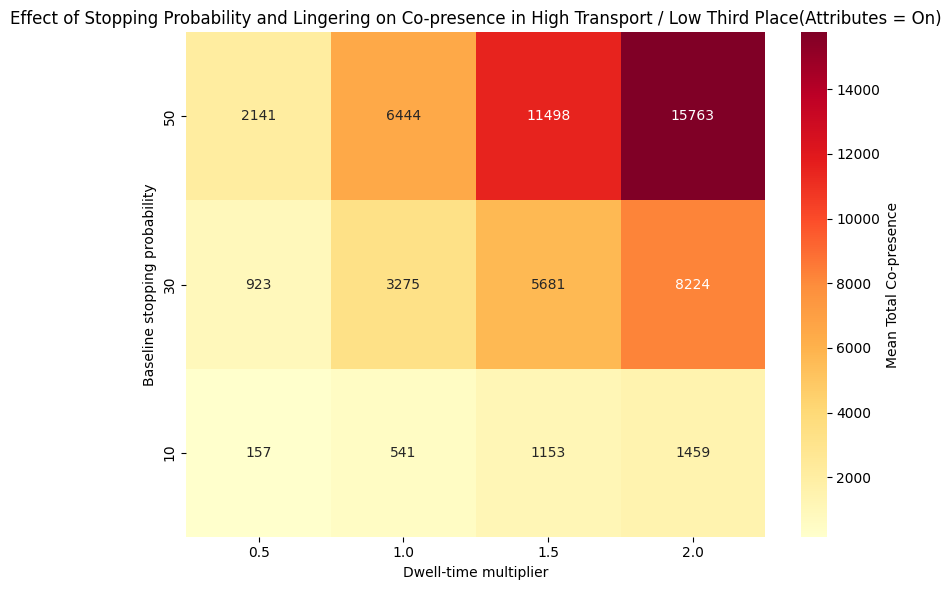

In [32]:
pivot = grouped_hi_low.pivot(
    index="baseline-stop-probability",
    columns="dwell-multiplier",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Effect of Stopping Probability and Lingering on Co-presence in High Transport / Low Third Place(Attributes = On)")
ax.set_xlabel("Dwell-time multiplier")
ax.set_ylabel("Baseline stopping probability")
plt.tight_layout()

## Low Transport High Third Place


In [38]:
stop_probs = [10, 30, 50]
dwell_multipliers = [0.5, 1.0, 1.5, 2.0]

base_rigid = 30
base_medium = 45
base_flexible = 60

results = []

seeds = [1, 2, 3, 4, 5]

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

for stop_prob in stop_probs:
    for multiplier in dwell_multipliers:
        
        rigid_dwell = base_rigid * multiplier
        medium_dwell = base_medium * multiplier
        flexible_dwell = base_flexible * multiplier
        
        # set parameters in NetLogo
        netlogo.command(f"set baseline-stop-probability {stop_prob}")
        netlogo.command(f"set rigid-dwell-time {rigid_dwell}")
        netlogo.command(f"set medium-dwell-time {medium_dwell}")
        netlogo.command(f"set flexible-dwell-time {flexible_dwell}")
        
        # keep other parameters constant
        netlogo.command("set number-of-people 200")
        netlogo.command("set third-place-search-radius 2")
        netlogo.command("set route-third-place-sample-size 50")
        netlogo.command("set encounter-odds-increment 0.10")
        netlogo.command("set encounter-weight 5")
        
        # run model
        for seed in seeds:
            netlogo.command(f"random-seed {seed}")
            netlogo.command("setup")
            netlogo.repeat_command("go", 1000)
        
            row = {
                "seed": seed,
                "baseline-stop-probability": stop_prob,
                "dwell-multiplier": multiplier,
                "rigid-dwell-time": rigid_dwell,
                "medium-dwell-time": medium_dwell,
                "flexible-dwell-time": flexible_dwell,
                    }

            for reporter in reporters:
                row[reporter] = netlogo.report(reporter)
            
            results.append(row)




explow_hi = pd.DataFrame(results)
explow_hi.head()

,seed,baseline-stop-probability,dwell-multiplier,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,visits-per-person,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,1,10,0.5,15.0,22.5,30.0,0.615,8.146929,1.30,1.1300,520.0,4.227642,19.0,10.0,0.186992,0.662224,0.606051
1,2,10,0.5,15.0,22.5,30.0,0.510,7.891553,1.05,1.1050,392.0,3.843137,21.0,9.0,0.117647,0.568554,0.570786
2,3,10,0.5,15.0,22.5,30.0,0.605,7.821770,0.85,1.0850,335.0,2.768595,24.0,6.0,0.140496,0.582812,0.610241
3,4,10,0.5,15.0,22.5,30.0,0.500,7.923640,1.35,1.1315,493.0,4.930000,20.0,5.0,0.220000,0.602152,0.551455
4,5,10,0.5,15.0,22.5,30.0,0.620,8.074152,1.30,1.1300,670.0,5.403226,25.0,9.0,0.137097,0.514971,0.554882


In [35]:
grouped_low_hi = explow_hi.groupby(["baseline-stop-probability", "dwell-multiplier"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped_low_hi


,baseline-stop-probability,dwell-multiplier,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,0.5,282.6,110.694625,0.436,0.71,0.155350,3.303594
1,10,1.0,724.0,329.635405,0.394,0.85,0.141712,9.164060
2,10,1.5,1592.0,681.473771,0.429,1.42,0.144544,18.177485
3,10,2.0,2469.2,642.256335,0.414,1.68,0.160999,29.592977
4,30,0.5,1588.6,559.517917,1.183,4.15,0.130428,6.622009
5,30,1.0,4390.0,684.340193,1.153,6.81,0.114556,18.999992
6,30,1.5,8740.4,2277.121933,1.172,10.71,0.121589,36.850899
7,30,2.0,13141.0,2396.588617,1.141,15.71,0.130099,57.394193
8,50,0.5,3462.8,543.290162,1.947,10.77,0.118572,8.863449
9,50,1.0,9661.6,1432.048463,1.841,20.13,0.126928,26.147908


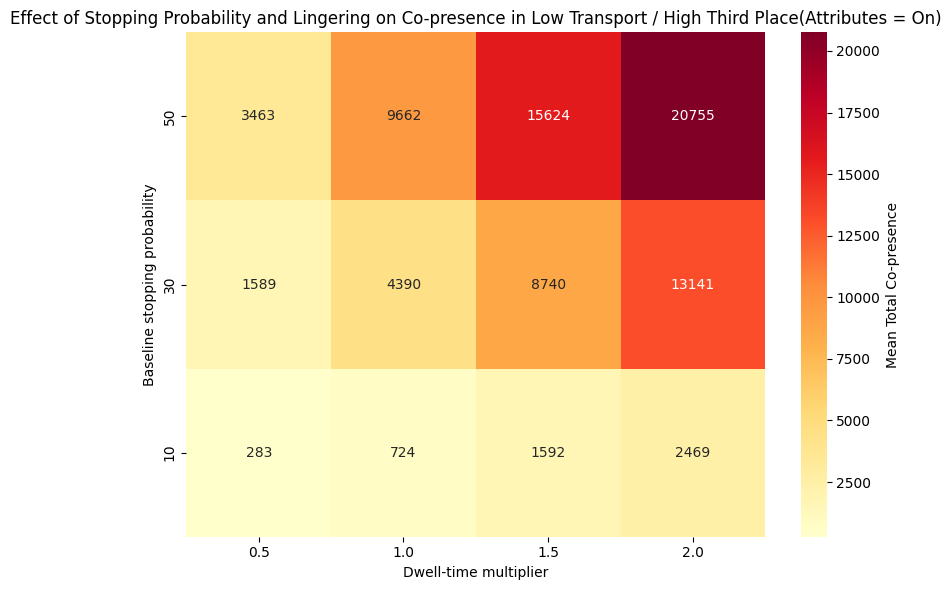

In [44]:
pivot = grouped_low_hi.pivot(
    index="baseline-stop-probability",
    columns="dwell-multiplier",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Effect of Stopping Probability and Lingering on Co-presence in Low Transport / High Third Place(Attributes = On)")
ax.set_xlabel("Dwell-time multiplier")
ax.set_ylabel("Baseline stopping probability")
plt.tight_layout()

## Low Transport Low Third Place

In [40]:
stop_probs = [10, 30, 50]
dwell_multipliers = [0.5, 1.0, 1.5, 2.0]

base_rigid = 30
base_medium = 45
base_flexible = 60

results = []

seeds = [1, 2, 3, 4, 5]

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

for stop_prob in stop_probs:
    for multiplier in dwell_multipliers:
        
        rigid_dwell = base_rigid * multiplier
        medium_dwell = base_medium * multiplier
        flexible_dwell = base_flexible * multiplier
        
        # set parameters in NetLogo
        netlogo.command(f"set baseline-stop-probability {stop_prob}")
        netlogo.command(f"set rigid-dwell-time {rigid_dwell}")
        netlogo.command(f"set medium-dwell-time {medium_dwell}")
        netlogo.command(f"set flexible-dwell-time {flexible_dwell}")
        
        # keep other parameters constant
        netlogo.command("set number-of-people 200")
        netlogo.command("set third-place-search-radius 2")
        netlogo.command("set route-third-place-sample-size 50")
        netlogo.command("set encounter-odds-increment 0.10")
        netlogo.command("set encounter-weight 5")
        
        # run model
        for seed in seeds:
            netlogo.command(f"random-seed {seed}")
            netlogo.command("setup")
            netlogo.repeat_command("go", 1000)
        
            row = {
                "seed": seed,
                "baseline-stop-probability": stop_prob,
                "dwell-multiplier": multiplier,
                "rigid-dwell-time": rigid_dwell,
                "medium-dwell-time": medium_dwell,
                "flexible-dwell-time": flexible_dwell,
                    }

            for reporter in reporters:
                row[reporter] = netlogo.report(reporter)
            
            results.append(row)




explow_low = pd.DataFrame(results)
explow_low.head()

,seed,baseline-stop-probability,dwell-multiplier,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,visits-per-person,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,1,10,0.5,15.0,22.5,30.0,0.615,8.146929,1.30,1.1300,520.0,4.227642,19.0,10.0,0.186992,0.662224,0.606051
1,2,10,0.5,15.0,22.5,30.0,0.510,7.891553,1.05,1.1050,392.0,3.843137,21.0,9.0,0.117647,0.568554,0.570786
2,3,10,0.5,15.0,22.5,30.0,0.605,7.821770,0.85,1.0850,335.0,2.768595,24.0,6.0,0.140496,0.582812,0.610241
3,4,10,0.5,15.0,22.5,30.0,0.500,7.923640,1.35,1.1315,493.0,4.930000,20.0,5.0,0.220000,0.602152,0.551455
4,5,10,0.5,15.0,22.5,30.0,0.620,8.074152,1.30,1.1300,670.0,5.403226,25.0,9.0,0.137097,0.514971,0.554882


In [41]:
grouped_low_low = explow_low.groupby(["baseline-stop-probability", "dwell-multiplier"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped_low_low


,baseline-stop-probability,dwell-multiplier,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,0.5,482.0,129.052315,0.570,1.17,0.160446,4.234520
1,10,1.0,1459.6,346.495022,0.546,2.04,0.153001,13.479397
2,10,1.5,3362.6,510.131650,0.575,3.49,0.144692,29.223269
3,10,2.0,4354.2,613.605900,0.518,3.50,0.140363,41.954116
4,30,0.5,3066.4,370.466328,1.661,9.13,0.134187,9.229347
5,30,1.0,9121.6,1489.993389,1.643,18.67,0.138602,27.640948
6,30,1.5,16401.2,2538.835895,1.685,31.79,0.139186,48.489296
7,30,2.0,20482.0,2839.899734,1.526,34.75,0.142741,66.924395
8,50,0.5,7204.4,423.196526,2.778,26.26,0.135122,12.981046
9,50,1.0,17277.0,1046.209109,2.608,47.93,0.124536,33.130431


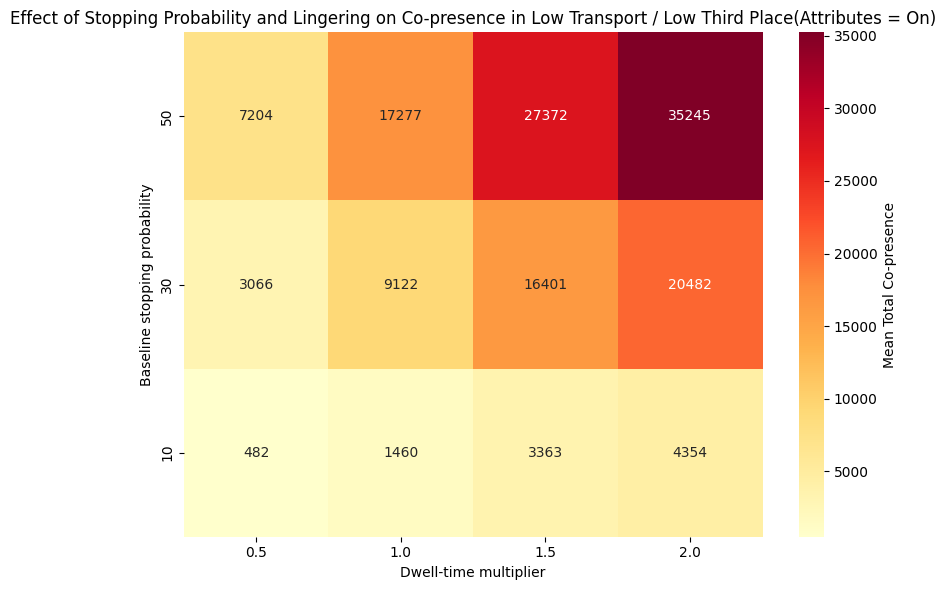

In [45]:
pivot = grouped_low_low.pivot(
    index="baseline-stop-probability",
    columns="dwell-multiplier",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Effect of Stopping Probability and Lingering on Co-presence in Low Transport / Low Third Place(Attributes = On)")
ax.set_xlabel("Dwell-time multiplier")
ax.set_ylabel("Baseline stopping probability")
plt.tight_layout()